# Inverse design problem

Key equation 
$$ -u''(x) + αu(x)^3 + V(x)u(x) = f(x) $$
with $u(0) = u(2\pi), u'(0) = u'(2\pi)$

In an inverse design problem, we are given a solution we want $u_{target}$ and we need to optimize one or more of the parameters such that the solution is the target function we want. 


In this study we will concentrate on optimizing the Potential `V`.  

In [37]:
include("../src/utils.jl")
include("../src/problem.jl")
include("../src/solvers.jl")

using Plots

# Set up beautiful plot styling with theme
theme(:dracula)
default(
    framestyle=:box,
    palette=:Set1_9,
    linewidth=2.5,
    markersize=6,
    size=(1000, 450),
    dpi=100,
    margin=8Plots.mm,
    grid=true,
    gridlinewidth=0.4,
    gridcolor=:lightgray,
    gridstyle=:dot,
    fontfamily="sans-serif",
    labelfontsize=12,
    guidefontsize=12,
    titlefontsize=13,
    legendfontsize=10,
    tickfontsize=11,
    legend=:best,
    background_color=:black,
    foreground_color=:white,
    fillalpha=0.3
)

### Hyperparameter Setup

In [38]:
N = 1000
xx = linspace(0, 2π, N)
ks = collect(fftfreq(N, N))
newton_steps = 100
println("Setup done for N=$N")

Setup done for N=1000


### Parameters

We will fix $\alpha$ to be 1.

For our testing, we fix different Potentials and solve for them using our solver. We will use the solutions as our u_targets, which will allow to always have positive potentials, and we can observe the optimisation in play.

Here we define different shape potential to better see different behavior based on the potential character:


- $V_1 = 1 + 0.5(x - π)²$: A parabola with positive 
- $V_2 = 6 - 0.5(x - π)²$: A parabola with negative 
- $V_3 = 3 + \cos(5x)$: A sinusoid function
- $V_4$: A spike function pointed up
- $V_5$: A spike function pointed down

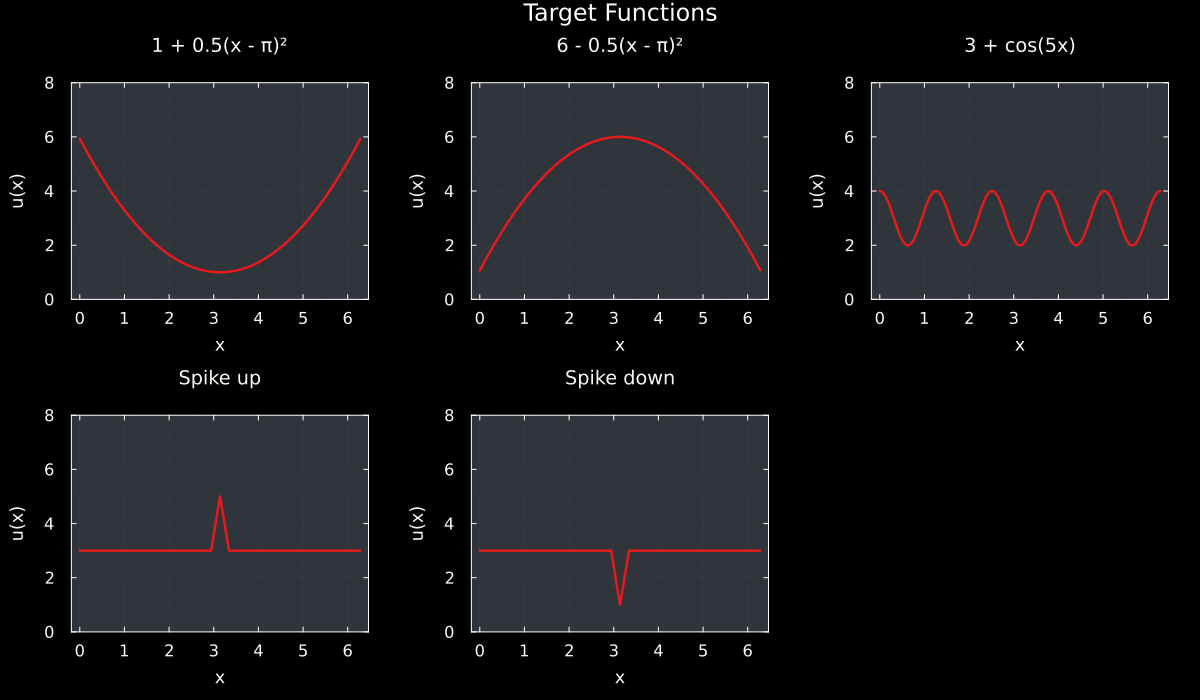

In [74]:
α = 1.

# Target functions
V_parabola_fn(x) = 1 .* (1 .+ 0.5 .* (x .- π).^2)
V_quad_fn(x) = 1 .* (6 .- 0.5.* (x .- π).^2)
V_cos_fn(x) = 1 .* (3 .+ cos.(5 .* x))

spike_slope = 10
V_spike_up_fn(x)   = 1 .* (2 .+ min.(max.(3 .+ spike_slope .* (x .- π), 1), max.(3 .- spike_slope .* (x .- π), 1)))
V_spike_down_fn(x) = 1 .* (4 .- min.(max.(3 .+ spike_slope .* (x .- π), 1), max.(3 .- spike_slope .* (x .- π), 1)))


# Discretization
targets = [V_parabola_fn(xx) V_quad_fn(xx) V_cos_fn(xx) V_spike_up_fn(xx) V_spike_down_fn(xx)]

titles = ["1 + 0.5(x - π)²" "6 - 0.5(x - π)²" "3 + cos(5x)" "Spike up" "Spike down"]
plots = [plot(xx, targets[:, i], title=titles[i], legend=false, xlabel="x", ylabel="u(x)", lw=2.5, ylims=(0, 8)) for i in 1:5]

plot(plots..., layout=(2, 3), plot_title="Target Functions", margin=6Plots.mm, size=(1200, 700))


As the forcing term f the first function we are going to use is 
$$f(x) = 2 + \cos{(2 x) + \sin(x)}$$


We can remark that we can solve directly for V using our Differential equation
$$ -u''(x) + αu(x)^3 + V(x)u(x) = f(x)$$
$$ V(x) =\frac{ u''(x) - αu(x)^3 + f(x)}{u(x)}$$

For the chosen f all of our solutions are going to be strictly positive, thus the direct solve would not have difficult situations like division by 0

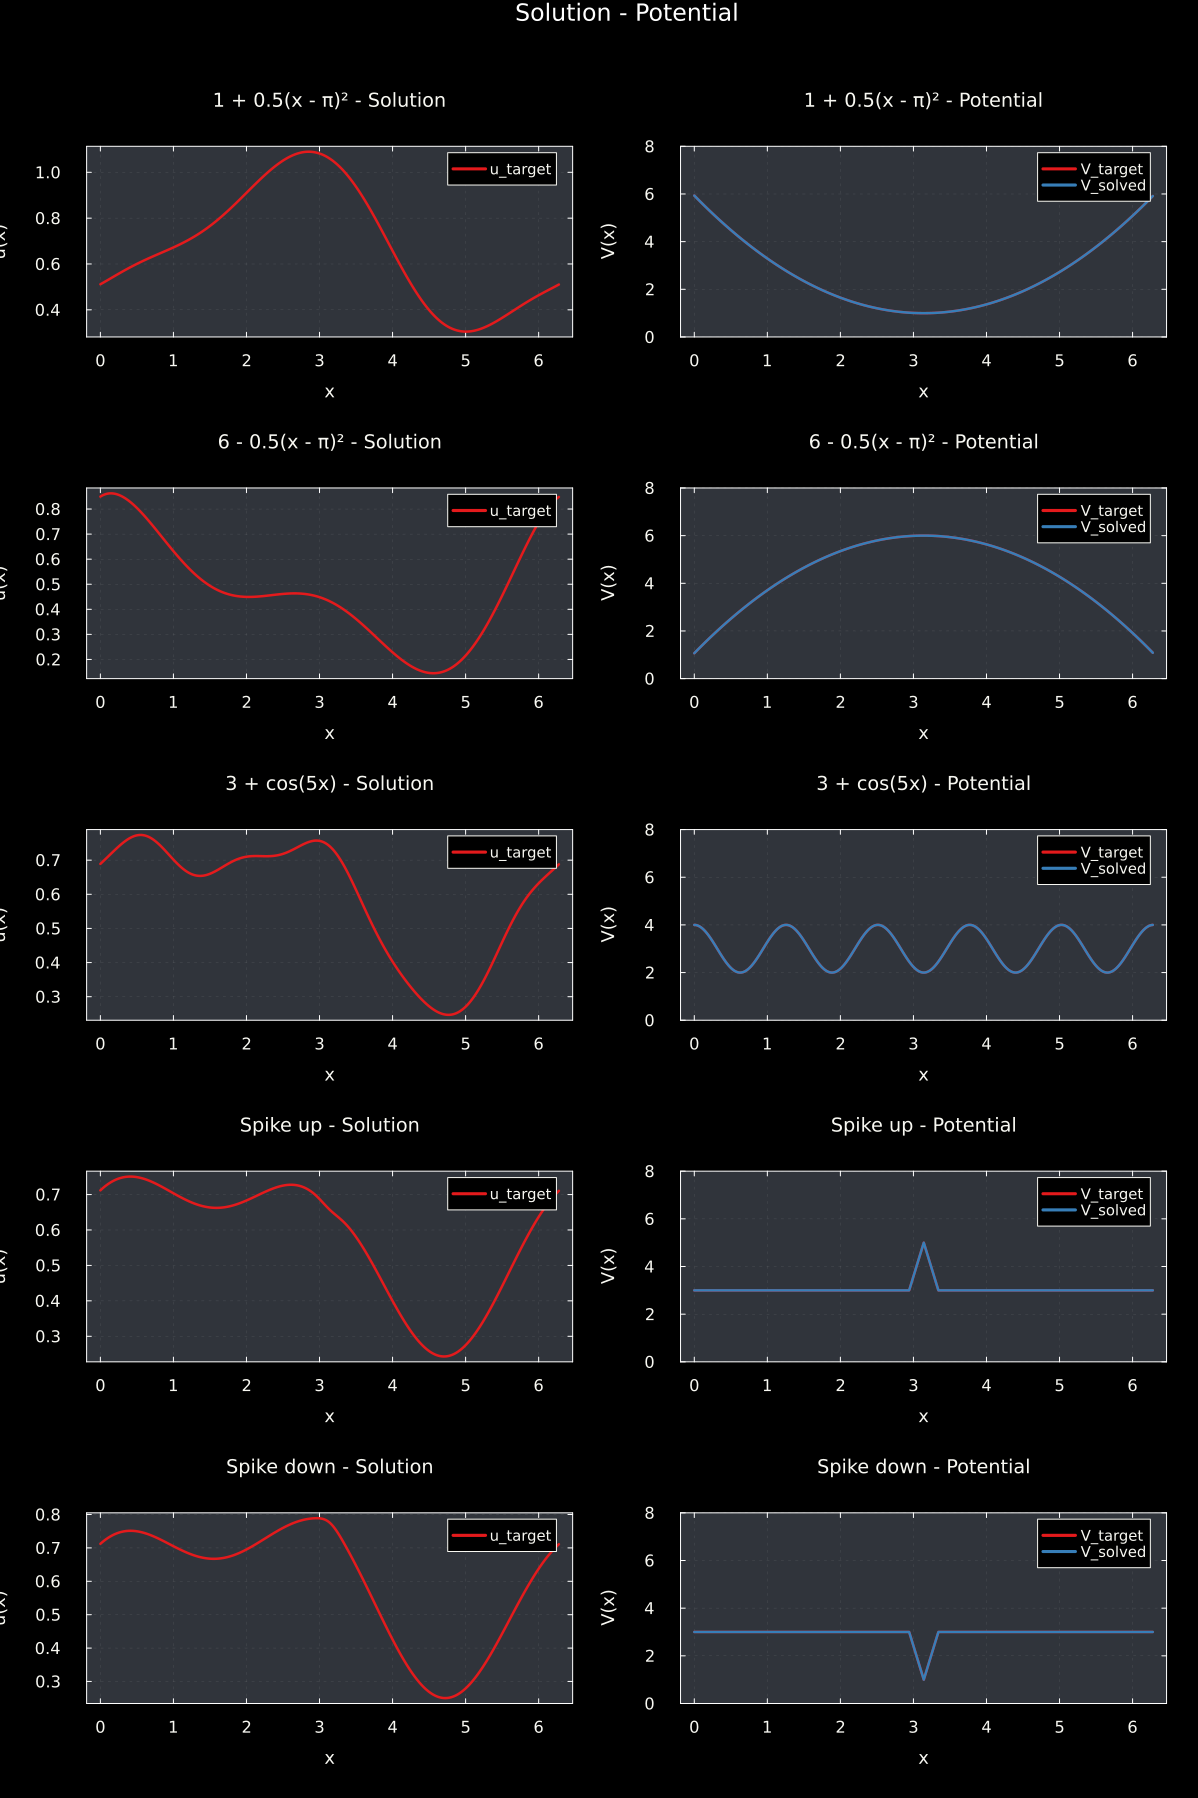

In [81]:
f_fn(x) = (2 + cos(2 * x) + sin(x))

# Create plots for each target
u_targets = zeros(5, N)
V_solveds = zeros(5, N)
plots_setup = []

for i in 1:5
    p = Problem(N=N, L=2π, α=α, f=f_fn)
    u_targets[i, :] = Newton_solve(p, targets[:, i], newton_steps)
    V_solveds[i, :] = (p.f.+ diff2_fourier(u_targets[i, :], p.ks) - α .* u_targets[i, :] .^3) ./ u_targets[i, :]
    
    p_u = plot(xx, u_targets[i, :], label="u_target", xlabel="x", ylabel="u(x)", title="$(titles[i]) - Solution", lw=2.5, legend=:topright)
    p_V = plot(xx, [targets[:, i] V_solveds[i, :]], label=["V_target" "V_solved"], xlabel="x", ylabel="V(x)", title="$(titles[i]) - Potential", lw=2.5, legend=:topright, ylims=(0, 8), size=(15, 20))
    
    push!(plots_setup, p_u, p_V)
end

plot(plots_setup..., layout=(5, 2), margin=6Plots.mm, size=(1200, 1800), plot_title="Solution - Potential")

Another f that we are going to test is
$$f_{annul}(x) = \sin(x)$$
For this f, all of the solutions have roots, thus causing anomalies

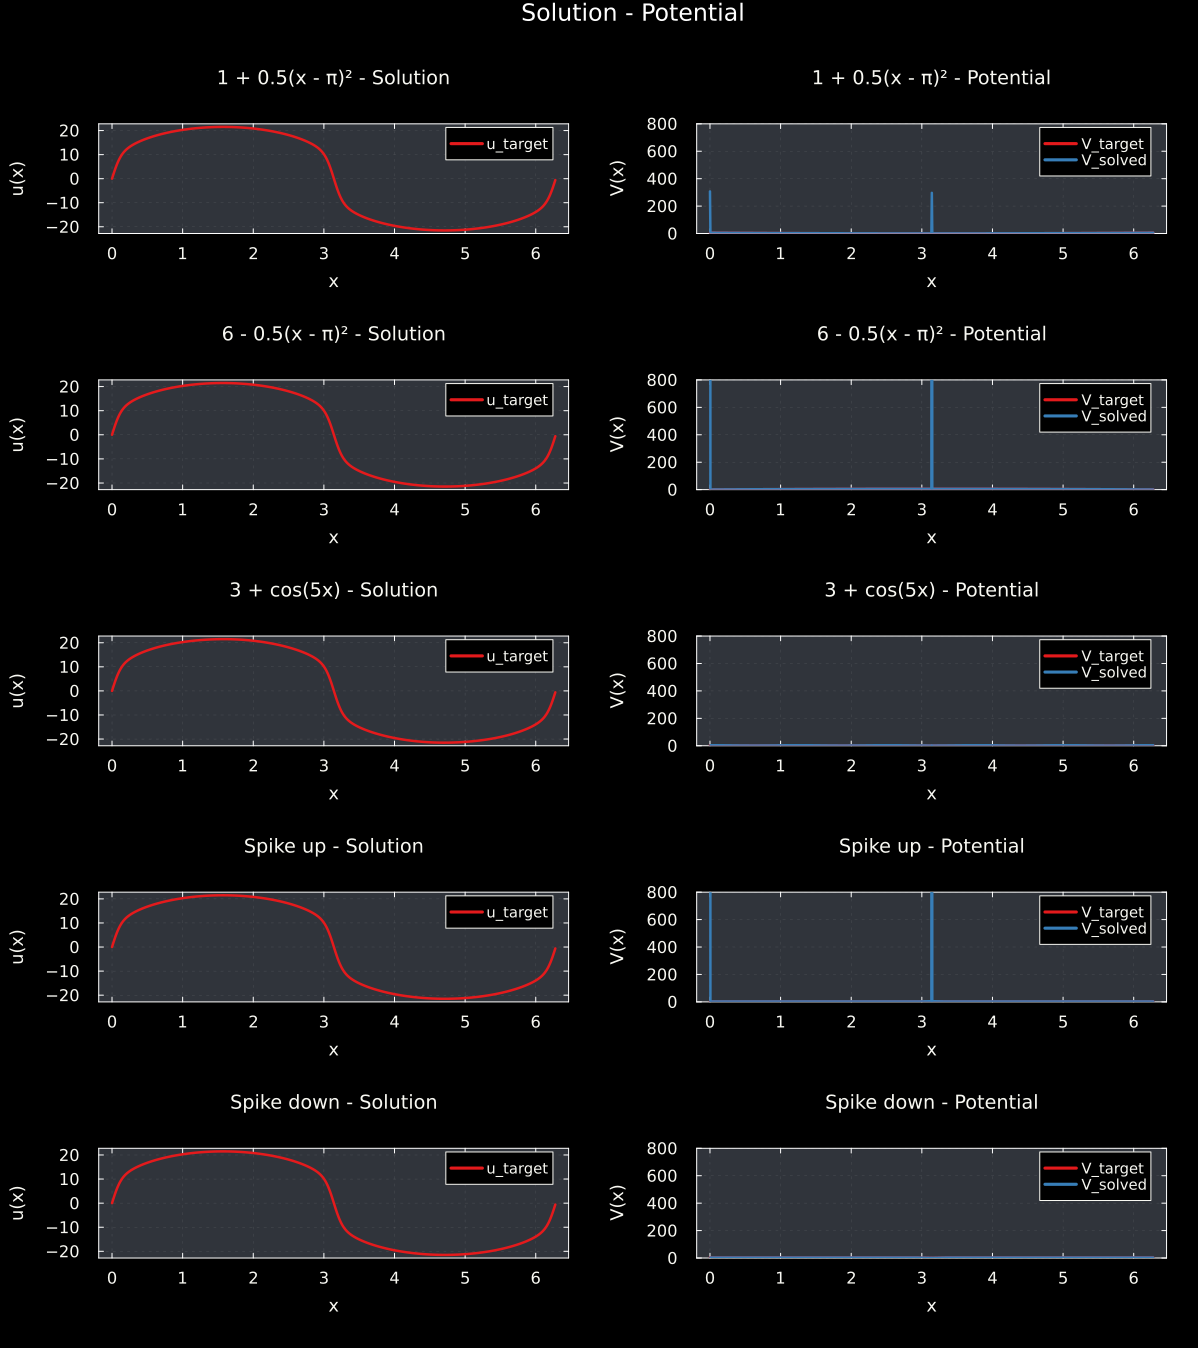

In [ ]:
# Define f_annuling as a function with 0 mean
f_annuling_fn(x) = sin(x)

# Create plots for each target
u_targets = zeros(5, N)
V_solveds = zeros(5, N)
plots_setup = []

for i in 1:5
    p = Problem(N=N, L=2π, α=α, f=f_annuling_fn)
    u_targets[i, :] = Newton_solve(p, targets[:, i], newton_steps)
    V_solveds[i, :] = (p.f.+ diff2_fourier(u_targets[i, :], p.ks) - p.α .* u_targets[i, :] .^3) ./ u_targets[i, :]
    
    p_u = plot(xx, u_targets[i, :], label="u_target", xlabel="x", ylabel="u(x)", title="$(titles[i]) - Solution", lw=2.5, legend=:topright)
    p_V = plot(xx, [targets[:, i] V_solveds[i, :]], label=["V_target" "V_solved"], xlabel="x", ylabel="V(x)", title="$(titles[i]) - Potential", lw=2.5, legend=:topright, ylims=(0, 800), size=(15, 20))
    
    push!(plots_setup, p_u, p_V)
end

plot(plots_setup..., layout=(5, 2), margin=6Plots.mm, size=(1200, 1350), plot_title="Solution - Potential")

We can see that we have anomalies around the roots of u. 

Despite having the direct way to solve for V, we are going to explore an optimization approach for the inverse design problem

We take as the loss functional: the function that we want to minimize the squared $l_2$-norm of the difference between the target u and the solution for a current V using our solver

In [55]:
loss(V_curr;p::Problem, u_target) = sum((Newton_solve(p, V_curr, newton_steps) - u_target) .^2)

loss (generic function with 1 method)

In [56]:
function create_targets(p::Problem)
    u_targets = zeros(5, p.N)
    targets = [V_parabola_fn(p.x) V_quad_fn(p.x) V_cos_fn(p.x) V_spike_up_fn(p.x) V_spike_down_fn(p.x)]
    for i in 1:5
        u_targets[i, :] = Newton_solve(p, targets[:, i], newton_steps)
    end
    return targets, u_targets
end

create_targets (generic function with 1 method)

## Gradients

The naive approach is to use Finite differences or Enzyme's already implemented Forward and Reverse AD to calculate $\frac{\partial loss}{\partial V}$ and use first order optimization methods to optimize for the loss

In [57]:
p = Problem(N=500, L=2π, f=f_fn)
targets, u_targets = create_targets(p)

([593.4802200544678 106.5197799455321 … 300.0 300.0; 589.5402739775529 110.45972602244704 … 300.0 300.0; … ; 585.6161192676798 114.38388073232018 … 300.0 300.0; 589.5402739775529 110.45972602244704 … 300.0 300.0], [0.005155739435092847 0.00518230708557224 … 0.005127125539001527 0.005138049270040692; 0.02280017274231626 0.02283871532763267 … 0.022471502259126204 0.02267416692272706; … ; 0.009956137095232015 0.009996845847159326 … 0.009868493741746021 0.009913350646000348; 0.009956137088655625 0.009996845853734882 … 0.009868493735166368 0.009913350652578198])

As a starting point for V function that we are going to later optimize in this notebook we are going to take $V(x) = 1.5$

Lets see the initial loss for the function $V(x) = 1.5$ with the forcing term f for different target Vs

In [58]:
using PrettyTables

V_test = ones(p.N) .* 1.5

# Compute losses 
losses_test = [loss(V_test; p=p, u_target = u_targets[i, :]) for i in 1:5]
losses_target = [loss(targets[:, i]; p=p, u_target = u_targets[i, :]) for i in 1:5]


# Create table
pretty_table(
    hcat(reshape(titles, 5), losses_test, losses_target),
    column_labels = ["Target", "Loss (V_test)", "Loss (V_target)"])

┌─────────────────┬───────────────┬─────────────────┐
│          Target │ Loss (V_test) │ Loss (V_target) │
├─────────────────┼───────────────┼─────────────────┤
│ 1 + 0.5(x - π)² │       374.846 │             0.0 │
│ 6 - 0.5(x - π)² │       379.177 │             0.0 │
│     3 + cos(5x) │       378.233 │             0.0 │
│        Spike up │       378.727 │             0.0 │
│      Spike down │       378.239 │             0.0 │
└─────────────────┴───────────────┴─────────────────┘


### Finite Differences

In [59]:
function FD(loss, V;eps=1e-8)
    grad = zeros(Float64, length(V))
    loss_base = loss(V)
    for i in 1:length(V)
        V_i = copy(V); V_i[i] += eps
        grad[i] = (loss(V_i) - loss_base) / eps
    end
    return grad
end

FD (generic function with 2 methods)

### Automatic Differentiation

In [60]:
function Forward_AD(loss, V)
    res = zeros(length(V))
    for i in 1:length(V)
        v = zeros(length(V))
        v[i] = 1
        (col,) = autodiff(set_runtime_activity(Forward), loss, Duplicated(V, v))
        res[i] = col
    end
    return res
    # grad, = gradient(set_runtime_activity(Forward), loss, Duplicated(V); chunk=Val(8))
    # return grad
end

function Backward_AD(loss, V)
    v = zeros(length(V))
    autodiff(set_runtime_activity(Reverse), loss, Active,  Duplicated(V, v))
    return v
end

Backward_AD (generic function with 2 methods)

In [61]:
V = 1.5 .* ones(p.N)

Enzyme.API.strictAliasing!(false)

println("FD")
fd_time = @elapsed grad_fd = FD(v -> loss(v; p=p, u_target=u_targets[1, :]), V)
println("Forward")
fad_time = @elapsed grad_fad = try
    Forward_AD(v -> loss(v; p=p, u_target=u_targets[1, :]), V)
catch e
    println("Forward AD Failed: $e")
    zeros(N)
end
println("Backward")

bad_time = @elapsed grad_bad = try Backward_AD(v -> loss(v; p=p, u_target=u_targets[1, :]), V)
catch e
    println("Backward AD Failed: $e")
    zeros(N)
end


FD
Forward
Forward AD Failed: Enzyme.Compiler.EnzymeRuntimeException(Cstring(0x00007ff3d514eda4))
Backward
Backward AD Failed: Enzyme.Compiler.EnzymeNoDerivativeError{Nothing, Nothing}(Cstring(0x00007ff337bff66a), nothing, nothing)


13.581343396

We observe that vanilla Enzyme AD is not capable to handle our Newton solve

#### Combating AD failure causes

The first issue we find is that Enzyme does not know how to handle the FFT. We get rid of fft calculations in the solver, precalculating the 2nd derivative operator.
Another issue is the conjugate gradient solver. In its implementation from the Krylov.jl there is supplementary operations for other features, which causes errors when computing the computational graph. We use the simpler CG Implementation from our library

In [62]:
using LinearAlgebra

Enzyme.API.strictAliasing!(false)

D2 = let
    M = zeros(p.N, p.N)
    for j in 1:p.N
        ej = zeros(p.N); ej[j] = 1.0
        M[:, j] = real(ifft(-p.ks.^2 .* fft(ej)))
    end
    M
end
Minv = zeros(p.N, p.N)


function setup_naive_ad()
    global N, D2, Minv    
    D2 = let
        M = zeros(p.N, p.N)
        for j in 1:p.N
            ej = zeros(p.N); ej[j] = 1.0
            M[:, j] = real(ifft(-p.ks.^2 .* fft(ej)))
        end
        M
    end
    c = 2.0
    Minv = zeros(p.N, p.N)
    for j in 1:p.N
        ej = zeros(p.N); ej[j] = 1.0
        Minv[:, j] = real(ifft(fft(ej) ./ (p.ks.^2 .+ c)))
    end
    return nothing
end

setup_naive_ad()


function Newton_solve_ad(p, V, n_iter; tol=1e-16)
    u = zeros(p.N)
    for i in 1:n_iter
        res = -D2 * u .+ p.α .* u.^3 .+ V .* u .- p.f
        applyJ    = δu -> -D2 * δu .+ (3α .* u.^2 .+ V) .* δu
        applyMinv = z  -> Minv * z
        step = cg_ad(applyJ, res, M=applyMinv, n_iter=100)
        u = u - step
        # if(l2norm(step)<tol)
        #     # println("Stop condition at step $i")
        #     return u
        # end
    end
    return u
end

loss_ad(V_curr;p::Problem, u_target) = sum((Newton_solve_ad(p, V_curr, newton_steps) - u_target) .^2)

loss_ad (generic function with 1 method)

### Adjoint Trick

Instead of differentiating through the exact way we solve the differential equation, we can use the adjoint trick to compute the gradient with higher accuracy and cheaper. 
This is possible through considering the theoretical problem
We know that 
$$F(u(V*), V*) = 0$$
We can differentiate with respect to V
$$\frac{\partial F}{\partial u} \frac{\partial u} {\partial V} \delta V + \frac{\partial F}{\partial V} \delta V = 0 $$
The thing we are interested in is exactly $\delta u = \frac{\partial u} {\partial V} \delta V $
$$\frac{\partial F}{\partial u} \delta u + \frac{\partial F}{\partial V} \delta V = 0 $$
Thus we can express $\delta u $ with help of the other terms, and using the fact that $\frac{\partial F}{\partial u}$ is the operator L that we use in the forward solve, calculated for the u converged
$$ \delta u = -L^{-1} \frac{\partial F}{\partial V} \delta V$$

The dependence of F from V is linear, given by the u. so the whole $\frac{\partial F}{\partial V} = \text{diag}(u)$

Now lets consider the loss function, that we will note I
$$I(V) = \| u(V) - u_0 \|^2$$
$$\delta I = I(V + \delta V) - I(V)= 2\langle u(V) - u_0, \delta u\rangle + O(\delta V ^2) = 2\langle u(V) - u_0, -L^{-1}\text{diag}(u)\delta V \rangle$$
L is a self adjoint operator, and as the inverse and adjoint commute, we can say that $L^{-1}$ is also self adjoint , thus we can carry it to the other side.
$$ = -2\langle L^{-1}(u(V) - u_0), \text{diag}(u)\delta V \rangle$$
We introduce the adjoint equation

$$L \lambda = u(V) - u_0$$

We had that L is HPD, so we can use the Krylov solver to calculate $\lambda$ very cheaply. This allows us to rewrite the top equation

$$\delta I = -2 \langle \lambda, \text{diag}(u)\delta V \rangle = \langle -2 \text{diag}(u) \lambda, \delta V \rangle + O(\delta V ^ 2)$$
This exactly identifies the gradient of the loss to be $\text{diag}(u) \lambda$

#### Gradient

In [ ]:
function adjoint_solve(p, V, u_target)
    u = Newton_solve(p, V, newton_steps)
    
    L = (result, du) -> result .= -diff2_fourier(du, p.ks) + 3 * p.α .* u .^2 .* du .+ V .* du
    op = LinearOperator(Float64, p.N, p.N, true, true, L)

    c = sum(3 * p.α .* u .^2 .+ V) / p.N
    P = (out, v) -> out .= real(ifft(fft(v) ./ (p.ks.^2 .+ c)))
    P_op = LinearOperator(Float64, p.N, p.N, true, true, P)

    λ, _ = cg(op, u - u_target, M = P_op, atol=1e-13, rtol=1e-11)
    # println("Lambda stats")
    # println(minimum(λ), sum(λ)/N, maximum(λ))
    return -2λ .* u
end

adjoint_solve (generic function with 1 method)

The form of $\lambda$

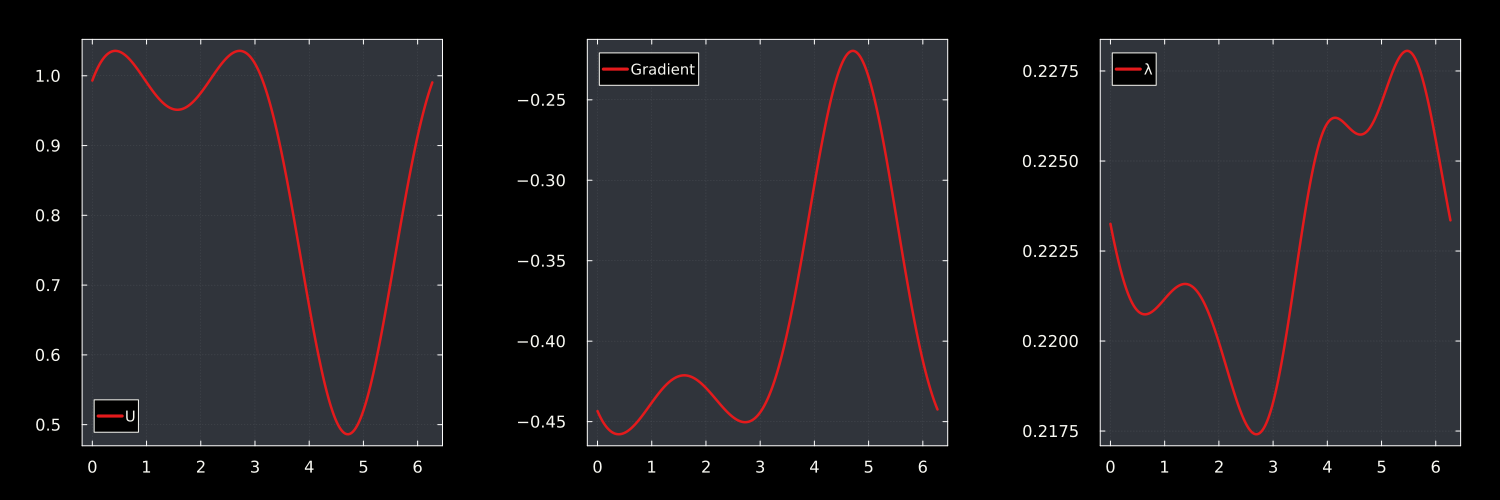

In [64]:
function adjoint_solve_test(p, V, u_target)
    u = Newton_solve(p, V, 20)
    
    L = (result, du) -> result .= -diff2_fourier(du, p.ks) + 3 * p.α .* u .^2 .* du .+ V .* du
    op = LinearOperator(Float64, p.N, p.N, true, true, L)

    c = sum(3 * p.α .* u .^2 .+ V) / p.N
    P = (out, v) -> out .= real(ifft(fft(v) ./ (p.ks.^2 .+ c)))
    P_op = LinearOperator(Float64, p.N, p.N, true, true, P)

    λ, _ = cg(op, u - u_target, M = P_op, atol=1e-13, rtol=1e-11)
    return u, -2λ .* u, λ
end
V = 1.5 .* ones(p.N)
u, grad, λ = adjoint_solve_test(p, V, u_targets[1, :])

plot_u = plot(p.x, u, label="U")
plot_grad = plot(p.x, grad, label="Gradient")
plot_lambda = plot(p.x, λ, label = "λ")

plot(plot_u, plot_grad, plot_lambda, layout= (1, 3), size=(1500, 500))

### Comparison of differentiation methods

In [65]:
println("FD")
fd_time = @elapsed grad_fd = FD(v -> loss_ad(v; p=p, u_target=u_targets[1, :]), V)

println("Forward")
fad_time = @elapsed grad_fad = Forward_AD(v -> sum((Newton_solve_ad(p, v, newton_steps) - u_targets[1, :]) .^2), V)

println("Backward")
bad_time = @elapsed grad_bad = Backward_AD(v -> sum((Newton_solve_ad(p, v, newton_steps) - u_targets[1, :]) .^2), V)


adj_time = @elapsed grad_adj = adjoint_solve(p, V, u_targets[1, :])


# Create comparison matrix
methods = ["Finite Differences", "Forward AD", "Backward AD", "Adjoint"]
grads = [grad_fd, grad_fad, grad_bad, grad_adj]
times = [fd_time, fad_time, bad_time, adj_time]

# Create difference matrix
diff_matrix = zeros(4, 4)
for i in 1:4, j in 1:4
    diff_matrix[i, j] = l2norm(grads[i] - grads[j])
end

# Create time comparison table
pretty_table(
    hcat(methods, times),
     column_labels=["Method", "Time (s)"])

# Create gradient differences table
pretty_table(
    hcat(methods, diff_matrix),
     column_labels=vcat(["Method"], methods),
    title = "Gradient Differences (L2 norm)",  display_size=(-1,-1))

# Forward_AD(v -> loss_ad(v; p=p, u_target=u_targets[1, :]), V)

FD
Forward


LoadError: InterruptException:

We can see that still naive backpropagation through the iterative solvers is fast, but nothing compares with the adjoint. We however see a difference of order $10^{-5}$ between ajdoint and AD methods, which can be explained by the fact that adjoint method is exact analytically, whereas the naive AD methods calculate the gradients for a iterative solver solution, which is not exactly our solution. 

## Optimization

### Gradient Descent

In [66]:
function gradient_descent(loss, get_gradient, V0, n_iter; η=0.1)
    stats = []
    V = copy(V0)
    for j in 1:n_iter
        grad = get_gradient(V)
        V -= η * grad
        if j % 100 == 0
            loss_base = loss(V)
            # println("iter $j — loss: $(round(loss_base, sigdigits=4))")
            push!(stats, loss_base)

        end
    end
    return V, stats
end

gradient_descent (generic function with 1 method)

### Gradient Descent with Adam Optimizer

In [67]:
using Optimisers

function adam_gradient_descent(loss, get_gradient, V0, n_iter; η=1e-2)
    stats = []
    V = copy(V0)
    state = Optimisers.setup(Optimisers.Adam(η), V)
    for j in 1:n_iter
        grad = get_gradient(V)
        state, V = Optimisers.update(state, V, grad)
        if j % 100 == 0
            loss_base = loss(V)
            push!(stats, loss_base)
        end
    end
    return V, stats
end

adam_gradient_descent (generic function with 1 method)

### L-BFGS

The gradient descent with Adam optimizer is a good approach for NNs.
In our case we can use L-BFGS optimizer which is a quasi-Newton method of optimization. 

The Newton method of optimization is using Newton method for root finding for the derivative(gradient) of the function. This involves the calculation of the hessian(second derivative) which is expensive.

L-BFGS is the efficient version of the BFGS optimizer which uses an approximation of the hessian and updates it every step of the iteration. L-BFGS does not store the hessian directly and uses the latest m steps to approximate it. 
Still the convergence is much faster then the simple gradient descent.

In [68]:
using Optim
function L_BFGS(loss, get_gradient, V0, n_iter)
    res = optimize(loss, (g, v) -> (g .= get_gradient(v)), V0, LBFGS(m=40),Optim.Options(iterations=n_iter, g_tol=1e-9, store_trace=true))
    return res.minimizer, [t.value for t in Optim.trace(res)]
end

L_BFGS (generic function with 1 method)

### Comparing Optimizers

**Forcing term: f**

In [69]:
p = Problem(N=500, L=2π, f=f_fn)
targets, u_targets = create_targets(p)

([593.4802200544678 106.5197799455321 … 300.0 300.0; 589.5402739775529 110.45972602244704 … 300.0 300.0; … ; 585.6161192676798 114.38388073232018 … 300.0 300.0; 589.5402739775529 110.45972602244704 … 300.0 300.0], [0.005155739435092847 0.00518230708557224 … 0.005127125539001527 0.005138049270040692; 0.02280017274231626 0.02283871532763267 … 0.022471502259126204 0.02267416692272706; … ; 0.009956137095232015 0.009996845847159326 … 0.009868493741746021 0.009913350646000348; 0.009956137088655625 0.009996845853734882 … 0.009868493735166368 0.009913350652578198])

In [70]:
V = 1.5 .* ones(p.N)

loss_fn(V) = loss(V; p=p, u_target=u_targets[3, :])
get_gradient(V) = adjoint_solve(p, V, u_targets[3, :])

V_gradient_descent, st_gradient_descent = gradient_descent(loss_fn, get_gradient, V, 10000)
V_adam, st_adam = adam_gradient_descent(loss_fn, get_gradient, V, 10000)
V_lbfgs, st_lbfgs = L_BFGS(loss_fn, get_gradient, V, 10000)

u_grad_descent= Newton_solve(p, V_gradient_descent, newton_steps)
u_adam= Newton_solve(p, V_adam, newton_steps)
u_lbfgs= Newton_solve(p, V_lbfgs, newton_steps)
    

500-element Vector{Float64}:
 0.007593014424967743
 0.007629700881880636
 0.007672434221800833
 0.007721288866021019
 0.007776344803123804
 0.007837687179655125
 0.007905405574682764
 0.007979592970692602
 0.008060344421170233
 0.008147755403153571
 0.008241919831349993
 0.008342927699392126
 0.008450862303793117
 ⋮
 0.007601715054775623
 0.007570876171768441
 0.007545187039660817
 0.007524786723245347
 0.007509788030032969
 0.00750028283017568
 0.007496347155848625
 0.007498045880687697
 0.007505436854156558
 0.007518574426917726
 0.007537512350270591
 0.007562306066081402

                   Final Loss Comparison
┌──────────────────┬────────────┬──────────────────────────┐
│           Method │ Final Loss │ Difference with V_target │
├──────────────────┼────────────┼──────────────────────────┤
│ Gradient Descent │      10.43 │                  295.876 │
│             Adam │    2.47407 │                  283.577 │
│           L-BFGS │ 3.05793e-7 │                  33.2082 │
└──────────────────┴────────────┴──────────────────────────┘


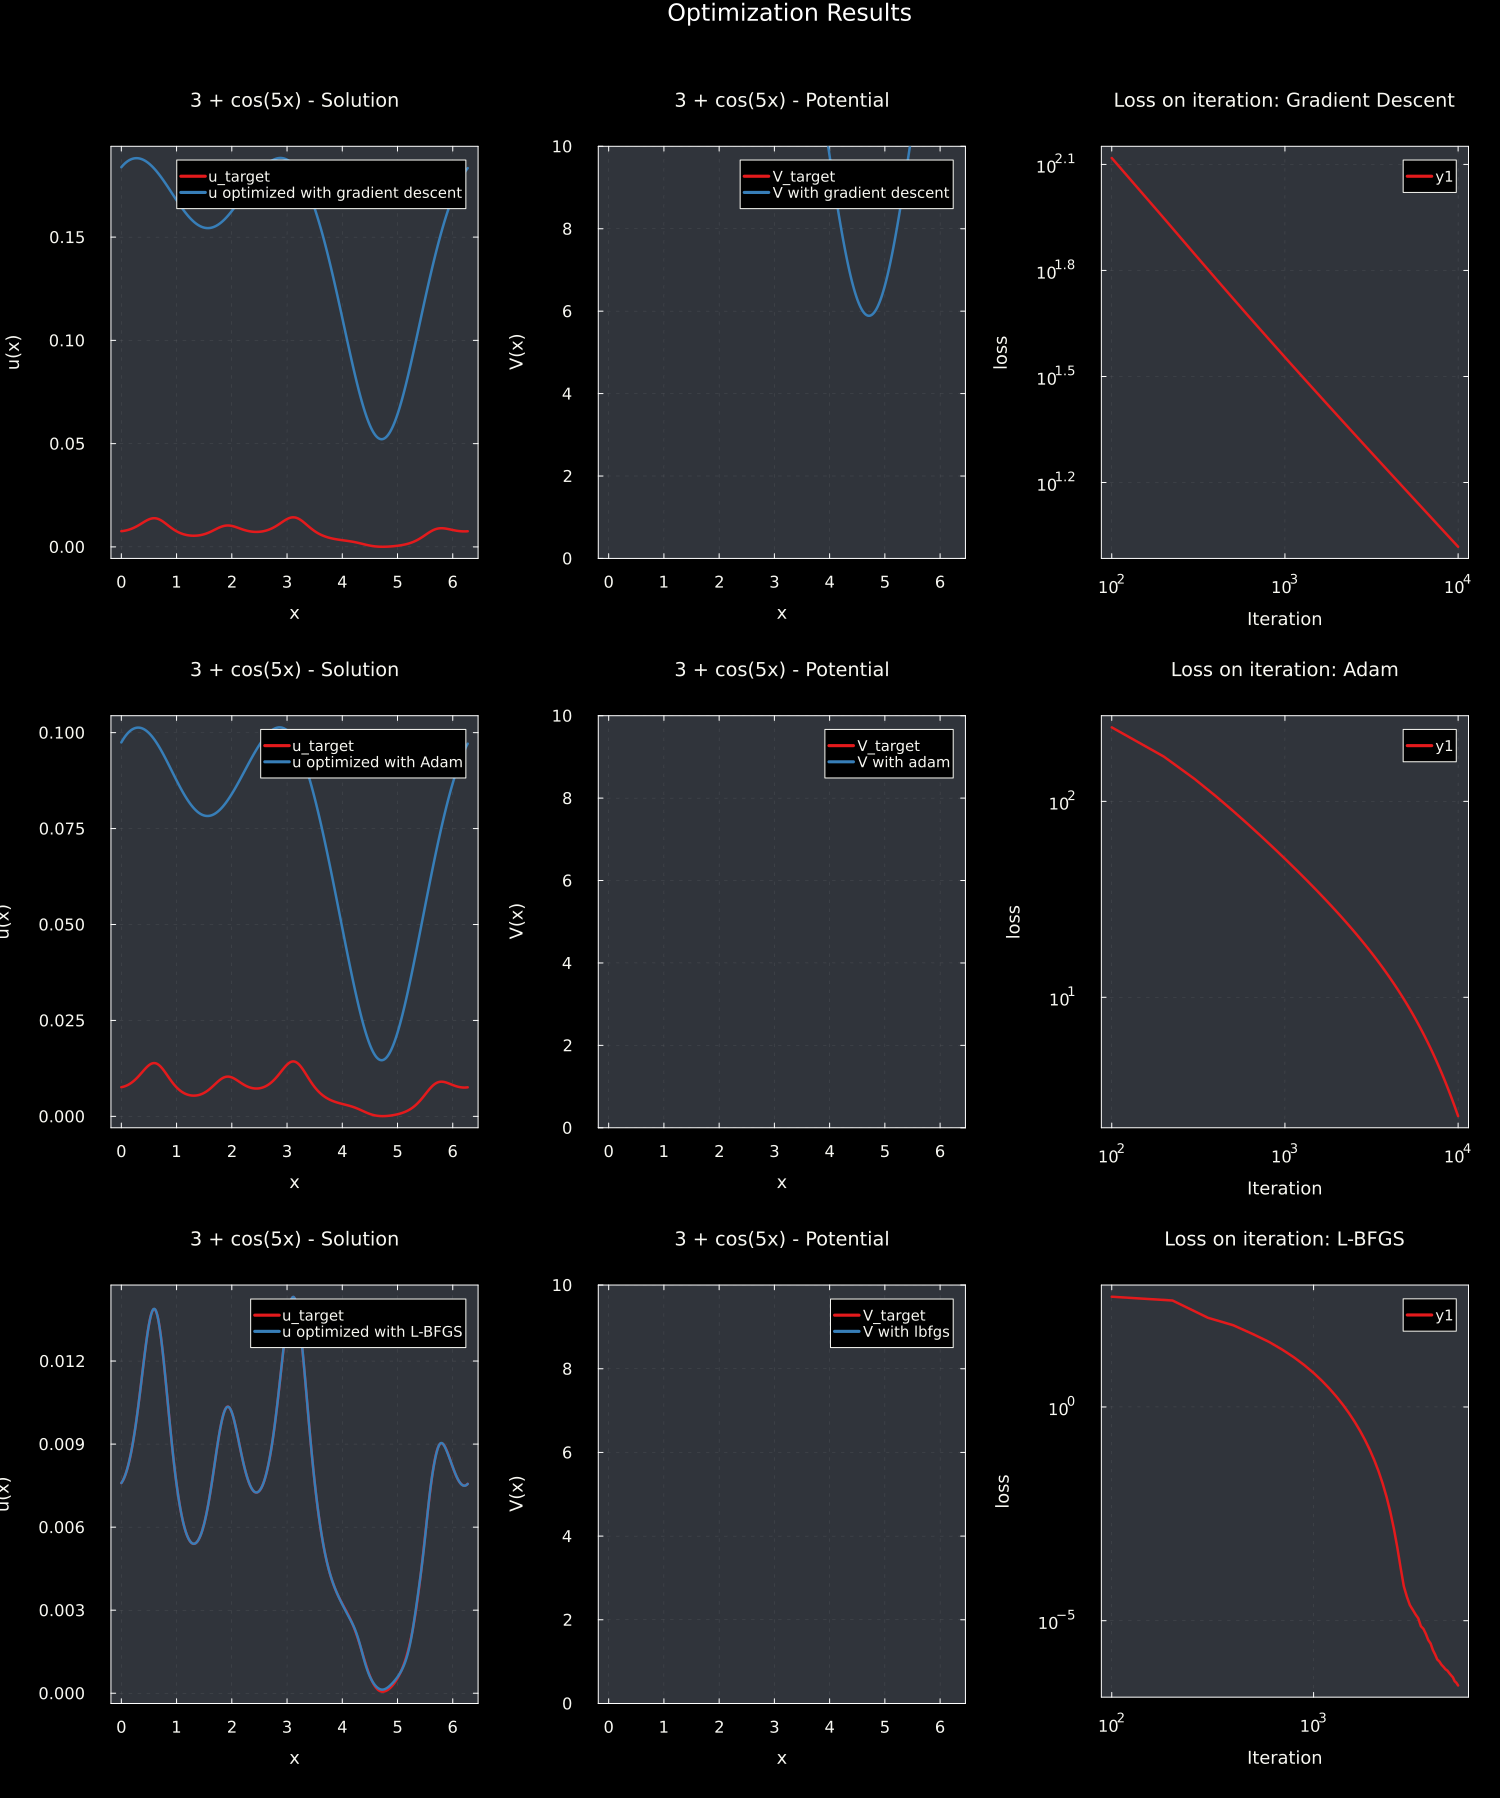

In [71]:
p_u1 = plot(p.x, [u_targets[3, :] u_grad_descent], label=["u_target" "u optimized with gradient descent"], xlabel="x", ylabel="u(x)", title="$(titles[3]) - Solution", lw=2.5, legend=:topright, size=(600, 400))
p_u2 = plot(p.x, [u_targets[3, :] u_adam], label=["u_target" "u optimized with Adam"], xlabel="x", ylabel="u(x)", title="$(titles[3]) - Solution", lw=2.5, legend=:topright, size=(600, 400))
p_u3 = plot(p.x, [u_targets[3, :] u_lbfgs], label=["u_target" "u optimized with L-BFGS"], xlabel="x", ylabel="u(x)", title="$(titles[3]) - Solution", lw=2.5, legend=:topright, size=(600, 400))


p_V1 = plot(p.x, [targets[:, 3] V_gradient_descent], label=["V_target" "V with gradient descent"], xlabel="x", ylabel="V(x)", title="$(titles[3]) - Potential", lw=2.5, legend=:topright, ylims=(0, 10), size=(600, 400))
p_V2 = plot(p.x, [targets[:, 3] V_adam], label=["V_target" "V with adam"], xlabel="x", ylabel="V(x)", title="$(titles[3]) - Potential", lw=2.5, legend=:topright, ylims=(0, 10), size=(600, 400))
p_V3 = plot(p.x, [targets[:, 3] V_lbfgs], label=["V_target" "V with lbfgs"], xlabel="x", ylabel="V(x)", title="$(titles[3]) - Potential", lw=2.5, legend=:topright, ylims=(0, 10), size=(600, 400))


p_stats1 = plot(100 * (1:length(st_gradient_descent)), st_gradient_descent, xlabel="Iteration", ylabel="loss",xscale=:log10, yscale=:log10, title="Loss on iteration: Gradient Descent",)

p_stats2 = plot(100 * (1:length(st_adam)), st_adam, xlabel="Iteration", ylabel="loss",xscale=:log10, yscale=:log10, title="Loss on iteration: Adam",)

p_stats3 = plot(100 * (1:length(st_lbfgs)), st_lbfgs, xlabel="Iteration", ylabel="loss", xscale=:log10, yscale=:log10, title="Loss on iteration: L-BFGS",)

plots_setup = [p_u1, p_V1, p_stats1, p_u2, p_V2, p_stats2, p_u3, p_V3, p_stats3]


# Table the final loss for each method with pretty tables
final_losses = [st_gradient_descent[end], st_adam[end], st_lbfgs[end]]
target_losses = [l2norm(V_gradient_descent - targets[:, 3]), l2norm(V_adam - targets[:, 3]), l2norm(V_lbfgs - targets[:, 3])]

method_names = ["Gradient Descent", "Adam", "L-BFGS"]


pretty_table(
    hcat(method_names, final_losses, target_losses),
    column_labels = ["Method", "Final Loss", "Difference with V_target"],
    title = "Final Loss Comparison")


plot(plots_setup..., layout=(3, 3), margin=6Plots.mm, size=(1500, 1800), plot_title="Optimization Results")

**Forcing term: $f_{annul}$**

In [23]:
p = Problem(N=500, L=2π, f=f_annuling_fn)
targets, u_targets = create_targets(p)

([5.934802200544679 1.065197799455321 … 3.0 3.0; 5.8954027397755295 1.1045972602244705 … 3.0 3.0; … ; 5.856161192676798 1.1438388073232018 … 3.0 3.0; 5.8954027397755295 1.1045972602244705 … 3.0 3.0], [-2.5315411638668364e-17 0.002661288769449357 … -0.005323067870982317 -0.0026612887694494576; -4.0905635953583104e-17 0.0030196379809529048 … -0.006037821692278744 -0.0030196379809529984; … ; -1.609172326365761e-17 0.0031177175025160486 … -0.006234927659453537 -0.0031177175025161475; -2.595554732289499e-17 0.0031178332595285566 … -0.006235159228323738 -0.0031178332595286585])

In [24]:
V = 3.0 .* ones(p.N)

loss_fn(V) = loss(V; p=p, u_target=u_targets[3, :])
get_gradient(V) = adjoint_solve(p, V, u_targets[3, :])

V_gradient_descent, st_gradient_descent = gradient_descent(loss_fn, get_gradient, V, 10000)
V_adam, st_adam = adam_gradient_descent(loss_fn, get_gradient, V, 10000)
V_lbfgs, st_lbfgs = L_BFGS(loss_fn, get_gradient, V, 1000)

u_grad_descent= Newton_solve(p, V_gradient_descent, newton_steps)
u_adam= Newton_solve(p, V_adam, newton_steps)
u_lbfgs= Newton_solve(p, V_lbfgs, newton_steps)

500-element Vector{Float64}:
 -1.4358792695119305e-8
  0.003221344710486866
  0.006442271260753194
  0.00966243005020459
  0.01288165719854498
  0.0160999933877916
  0.019317667993397358
  0.022535037314802154
  0.025752490528926048
  0.028970344116165583
  0.032188747711609234
  0.03540762120521419
  0.038626635291611
  ⋮
 -0.03862663351389634
 -0.03540762798270045
 -0.03218876122854481
 -0.028970362770022268
 -0.025752512947807244
 -0.02253506236381257
 -0.01931769477074437
 -0.016100021211654766
 -0.012881685585957247
 -0.009662458689310907
 -0.006442299977842459
 -0.0032213734331389536

                    Final Loss Comparison
┌──────────────────┬─────────────┬──────────────────────────┐
│           Method │  Final Loss │ Difference with V_target │
├──────────────────┼─────────────┼──────────────────────────┤
│ Gradient Descent │  0.00964301 │                 0.640752 │
│             Adam │ 1.79785e-11 │                0.0828336 │
│           L-BFGS │ 9.79875e-10 │                 0.160529 │
└──────────────────┴─────────────┴──────────────────────────┘


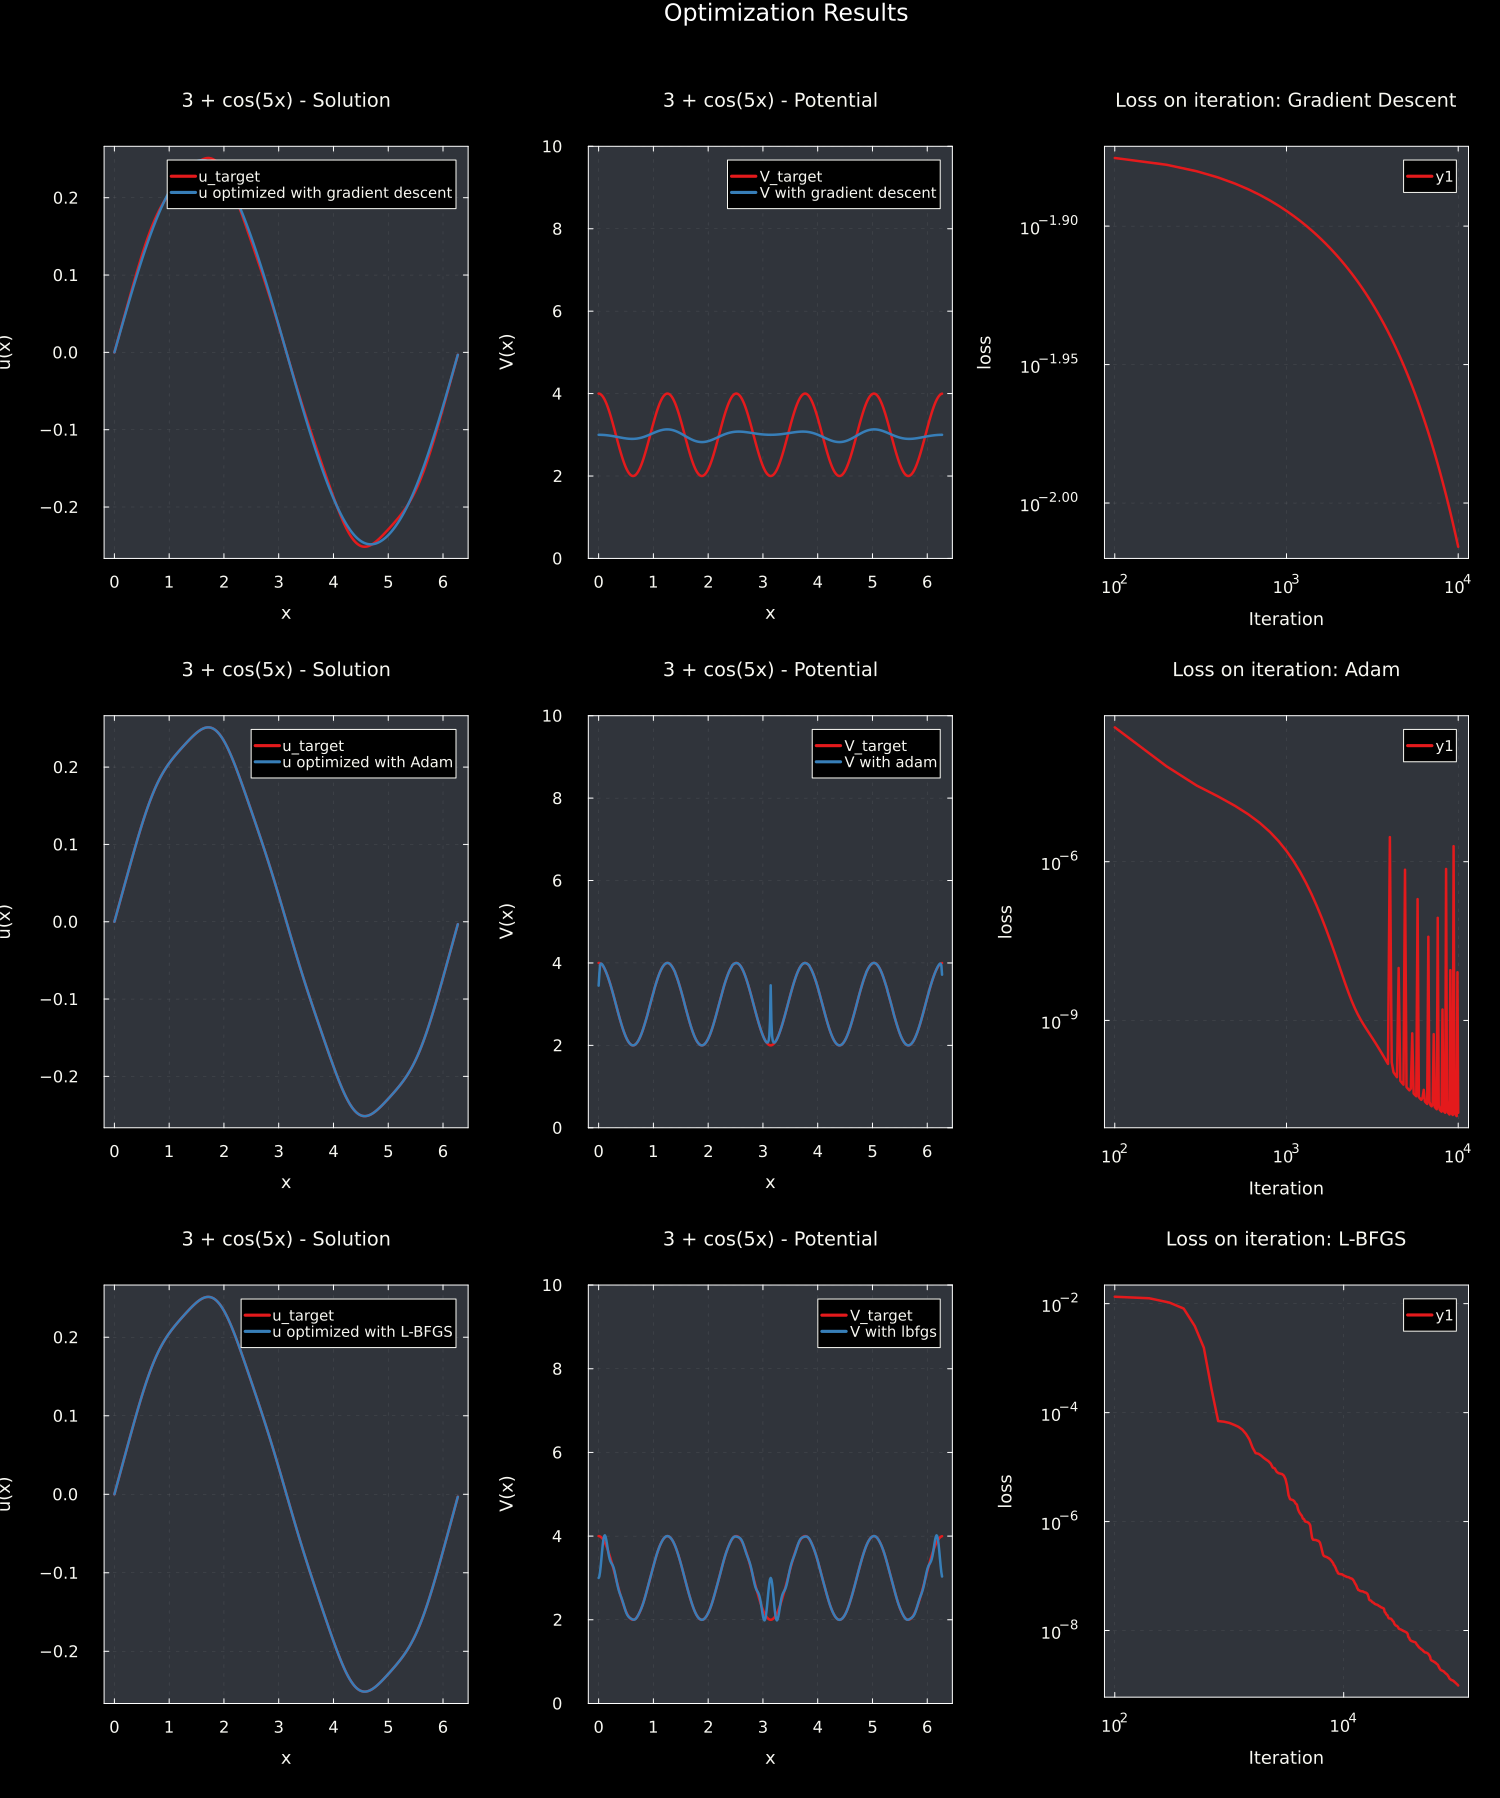

In [25]:
p_u1 = plot(p.x, [u_targets[3, :] u_grad_descent], label=["u_target" "u optimized with gradient descent"], xlabel="x", ylabel="u(x)", title="$(titles[3]) - Solution", lw=2.5, legend=:topright, size=(600, 400))
p_u2 = plot(p.x, [u_targets[3, :] u_adam], label=["u_target" "u optimized with Adam"], xlabel="x", ylabel="u(x)", title="$(titles[3]) - Solution", lw=2.5, legend=:topright, size=(600, 400))
p_u3 = plot(p.x, [u_targets[3, :] u_lbfgs], label=["u_target" "u optimized with L-BFGS"], xlabel="x", ylabel="u(x)", title="$(titles[3]) - Solution", lw=2.5, legend=:topright, size=(600, 400))


p_V1 = plot(p.x, [targets[:, 3] V_gradient_descent], label=["V_target" "V with gradient descent"], xlabel="x", ylabel="V(x)", title="$(titles[3]) - Potential", lw=2.5, legend=:topright, ylims=(0, 10), size=(600, 400))
p_V2 = plot(p.x, [targets[:, 3] V_adam], label=["V_target" "V with adam"], xlabel="x", ylabel="V(x)", title="$(titles[3]) - Potential", lw=2.5, legend=:topright, ylims=(0, 10), size=(600, 400))
p_V3 = plot(p.x, [targets[:, 3] V_lbfgs], label=["V_target" "V with lbfgs"], xlabel="x", ylabel="V(x)", title="$(titles[3]) - Potential", lw=2.5, legend=:topright, ylims=(0, 10), size=(600, 400))


p_stats1 = plot(100 * (1:length(st_gradient_descent)), st_gradient_descent, xlabel="Iteration", ylabel="loss",xscale=:log10, yscale=:log10, title="Loss on iteration: Gradient Descent",)

p_stats2 = plot(100 * (1:length(st_adam)), st_adam, xlabel="Iteration", ylabel="loss",xscale=:log10, yscale=:log10, title="Loss on iteration: Adam",)

p_stats3 = plot(100 * (1:length(st_lbfgs)), st_lbfgs, xlabel="Iteration", ylabel="loss", xscale=:log10, yscale=:log10, title="Loss on iteration: L-BFGS",)

plots_setup = [p_u1, p_V1, p_stats1, p_u2, p_V2, p_stats2, p_u3, p_V3, p_stats3]


# Table the final loss for each method with pretty tables
final_losses = [st_gradient_descent[end], st_adam[end], st_lbfgs[end]]
target_losses = [l2norm(V_gradient_descent - targets[:, 3]), l2norm(V_adam - targets[:, 3]), l2norm(V_lbfgs - targets[:, 3])]

method_names = ["Gradient Descent", "Adam", "L-BFGS"]


pretty_table(
    hcat(method_names, final_losses, target_losses),
    column_labels = ["Method", "Final Loss", "Difference with V_target"],
    title = "Final Loss Comparison")


plot(plots_setup..., layout=(3, 3), margin=6Plots.mm, size=(1500, 1800), plot_title="Optimization Results")

## Regularization

A few methods can be employed to combat the anomalies(spikes). One is to penalize for non smoothness of the function

The smoothness can be qualified using the first derivative. Some logical factors to try are 
- $R_1(V) = \int^1_0 |V'(x)|dx$
- $R_2(V) = \int^1_0 (V'(x))^2dx$

The loss will become 
$$I(V)  = \|u*(V) - u_{target} \| + \beta R(V)$$
where $\beta$ controls the normalisation strength

the gradient becomes $-2 \text{diag}(u) \lambda + \beta \frac{\partial R}{\partial V}$

For $R_2$ be get $-2 V''(x)$ 
For $R_1$ is is harder, as the absolute value function is not differentiable at point 0. 

we can modify it slightly to be $R_1(V, \epsilon) = \int^1_0 \sqrt{V'(x)^2 + \epsilon^2}dx$


The gradient for this modified version is $- \frac{d}{dx}( \frac{|V'|}{ \sqrt{(V')^2 + \epsilon^2 } })$

In [26]:
β = 1e-10
function R_2(p, V) 
    return sum(diff_fourier(V, p.ks).^2)/p.N
end
function grad_R_2(p, V)
    return - 2 .* diff2_fourier(V, p.ks) ./ p.N
end

function R_1(p, V;eps=1e-8)
    sum(sqrt.(diff_fourier(V, p.ks).^2 .+ eps^2))/p.N
end

function grad_R_1(p, V; eps=1e-8)
    d1 = diff_fourier(V, p.ks)
    return -diff_fourier(d1 ./ sqrt.(d1.^2 .+ eps^2), p.ks) ./ p.N
end


function reg_adjoint_solve(p, V, u_target; grad_R = grad_R_2)
    u = Newton_solve(p, V, 20)
    
    L = (result, du) -> result .= -diff2_fourier(du, p.ks) + 3 * p.α .* u .^2 .* du .+ V .* du
    op = LinearOperator(Float64, p.N, p.N, true, true, L)

    c = sum(3 * p.α .* u .^2 .+ V) / p.N
    P = (out, v) -> out .= real(ifft(fft(v) ./ (p.ks.^2 .+ c)))
    P_op = LinearOperator(Float64, p.N, p.N, true, true, P)

    λ, _ = cg(op, u - u_target, M = P_op, atol=1e-13, rtol=1e-11)
    
    return -2λ .* u + β .* grad_R(p, V)
end

loss_reg(V_curr;p, u_target, R = R_2) = loss(V_curr; p=p, u_target=u_target) + β * R(p, V_curr)

loss_reg (generic function with 1 method)

In [27]:
p = Problem(N=500, L=2π, f=f_annuling_fn)
targets, u_targets = create_targets(p)

([5.934802200544679 1.065197799455321 … 3.0 3.0; 5.8954027397755295 1.1045972602244705 … 3.0 3.0; … ; 5.856161192676798 1.1438388073232018 … 3.0 3.0; 5.8954027397755295 1.1045972602244705 … 3.0 3.0], [-2.5315411638668364e-17 0.002661288769449357 … -0.005323067870982317 -0.0026612887694494576; -4.0905635953583104e-17 0.0030196379809529048 … -0.006037821692278744 -0.0030196379809529984; … ; -1.609172326365761e-17 0.0031177175025160486 … -0.006234927659453537 -0.0031177175025161475; -2.595554732289499e-17 0.0031178332595285566 … -0.006235159228323738 -0.0031178332595286585])

Tests for $R_2$

loss: 11.395599109164538,  V-error: 1445.0   iters: 1001
loss: 4.164125006815255,  V-error: 1648.0   iters: 1001
loss: 7.7487877507628165,  V-error: 1563.0   iters: 1001
loss: 7.6657652249741774,  V-error: 1641.0   iters: 1001
loss: 7.672189157833267,  V-error: 1622.0   iters: 1001


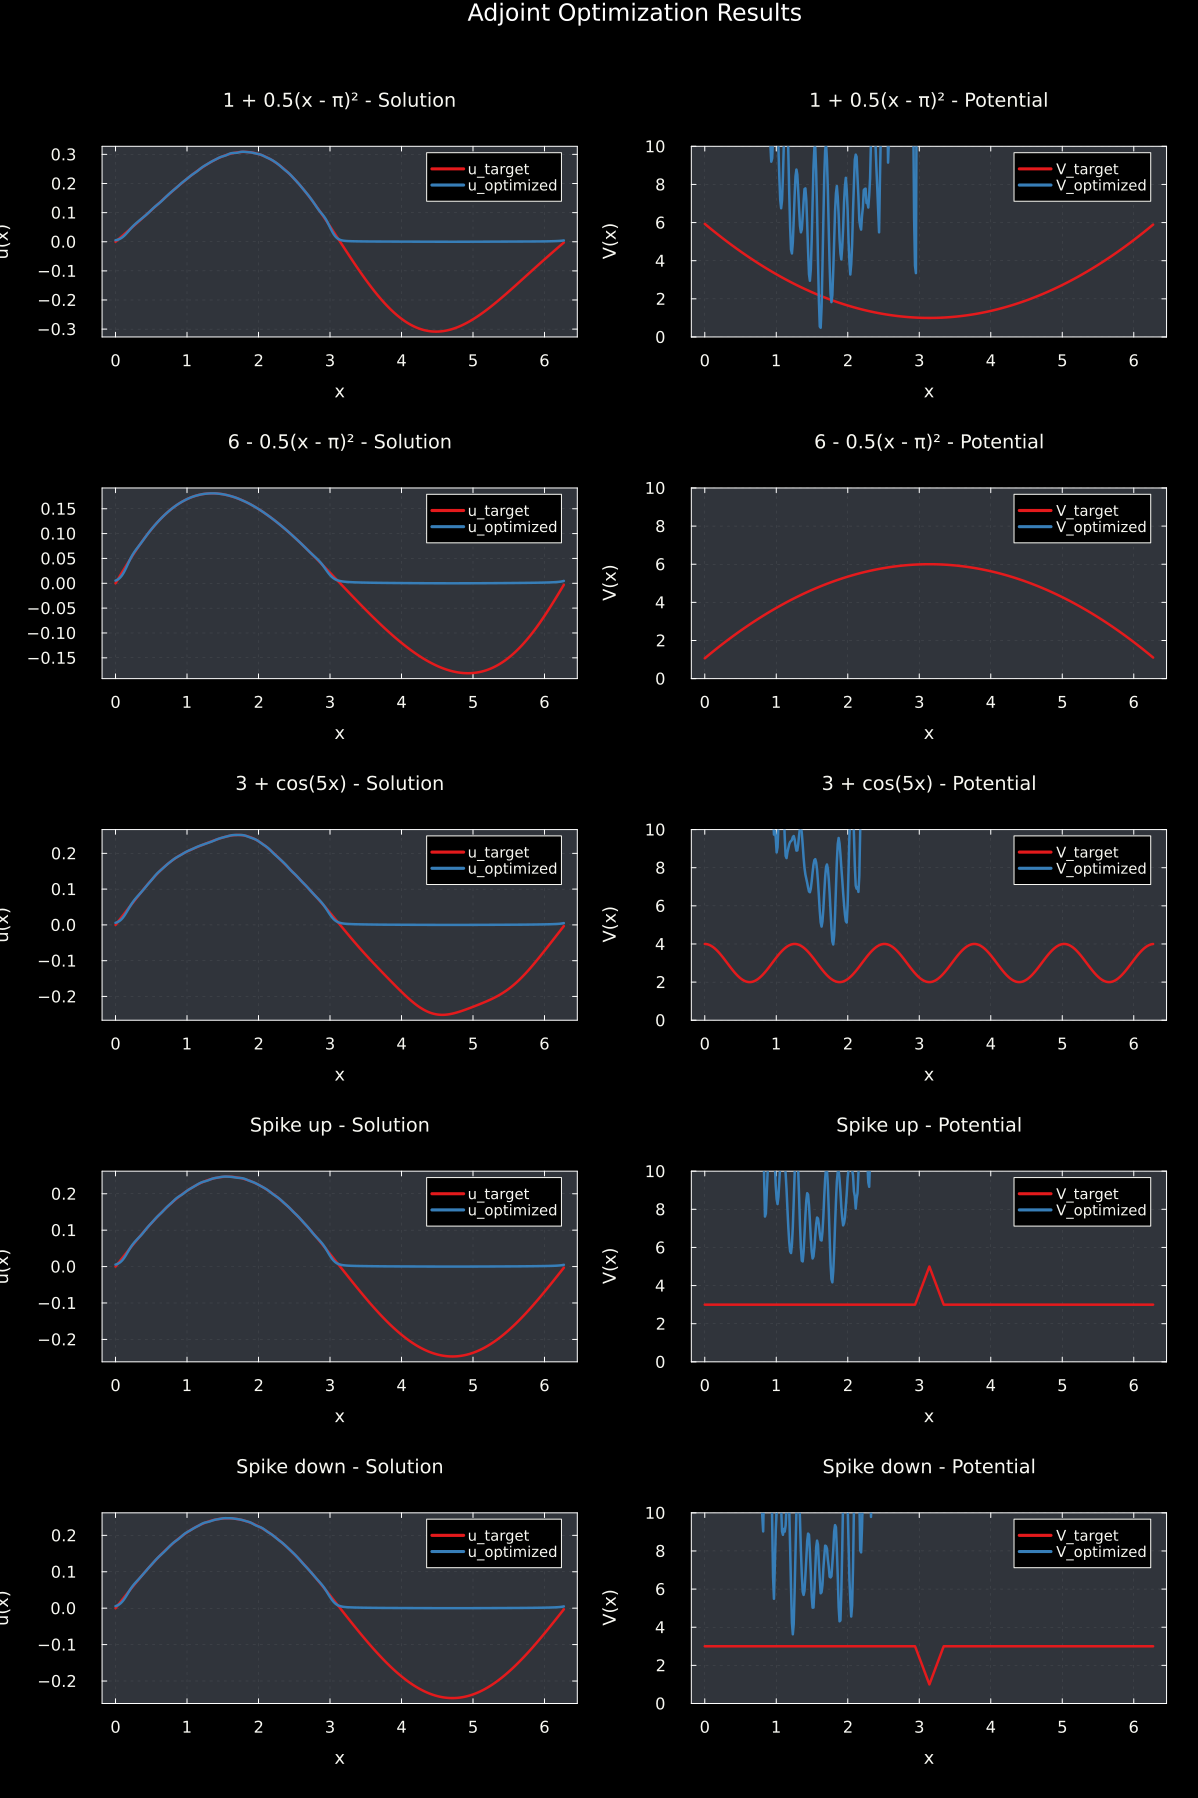

In [36]:
V = 2 .* ones(p.N)


β = 5e-9
# Optimize for each target
V_optimized = []
for i in 1:5

    loss_fn(V) = loss_reg(V; p=p, u_target=u_targets[i, :], R=R_2)
    get_gradient(V) = reg_adjoint_solve(p, V, u_targets[i, :], grad_R=grad_R_2)

    res, st = L_BFGS(loss_fn, get_gradient, V, 1000)
    push!(V_optimized, res)

    println("loss: ", loss(res; p=p, u_target=u_targets[i, :]), ",  V-error: ", round(l2norm(res - targets[:,i]), sigdigits=4),
                "   iters: ", length(st))
end


# Create plots for each target
plots_setup = []

for i in 1:5
    u_sol = Newton_solve(p, V_optimized[i], newton_steps)
    
    p_u = plot(p.x, [u_targets[i, :] u_sol], label=["u_target" "u_optimized"], xlabel="x", ylabel="u(x)", title="$(titles[i]) - Solution", lw=2.5, legend=:topright, size=(600, 400))
    p_V = plot(p.x, [targets[:, i] V_optimized[i]], label=["V_target" "V_optimized"], xlabel="x", ylabel="V(x)", title="$(titles[i]) - Potential", lw=2.5, legend=:topright, ylims=(0, 10), size=(600, 400))
    
    push!(plots_setup, p_u, p_V)
end

plot(plots_setup..., layout=(5, 2), margin=6Plots.mm, size=(1200, 1800), plot_title="Adjoint Optimization Results")

Tests for $R_1$

loss: 2.384659621073186e-8,  V-error: 0.4931   iters: 1001
loss: 3.560547741405708e-9,  V-error: 0.4178   iters: 1001
loss: 2.687163838463381e-9,  V-error: 0.2108   iters: 1001
loss: 4.7241898731193134e-9,  V-error: 0.3224   iters: 1001
loss: 1.3724905007966773e-9,  V-error: 0.1479   iters: 1001


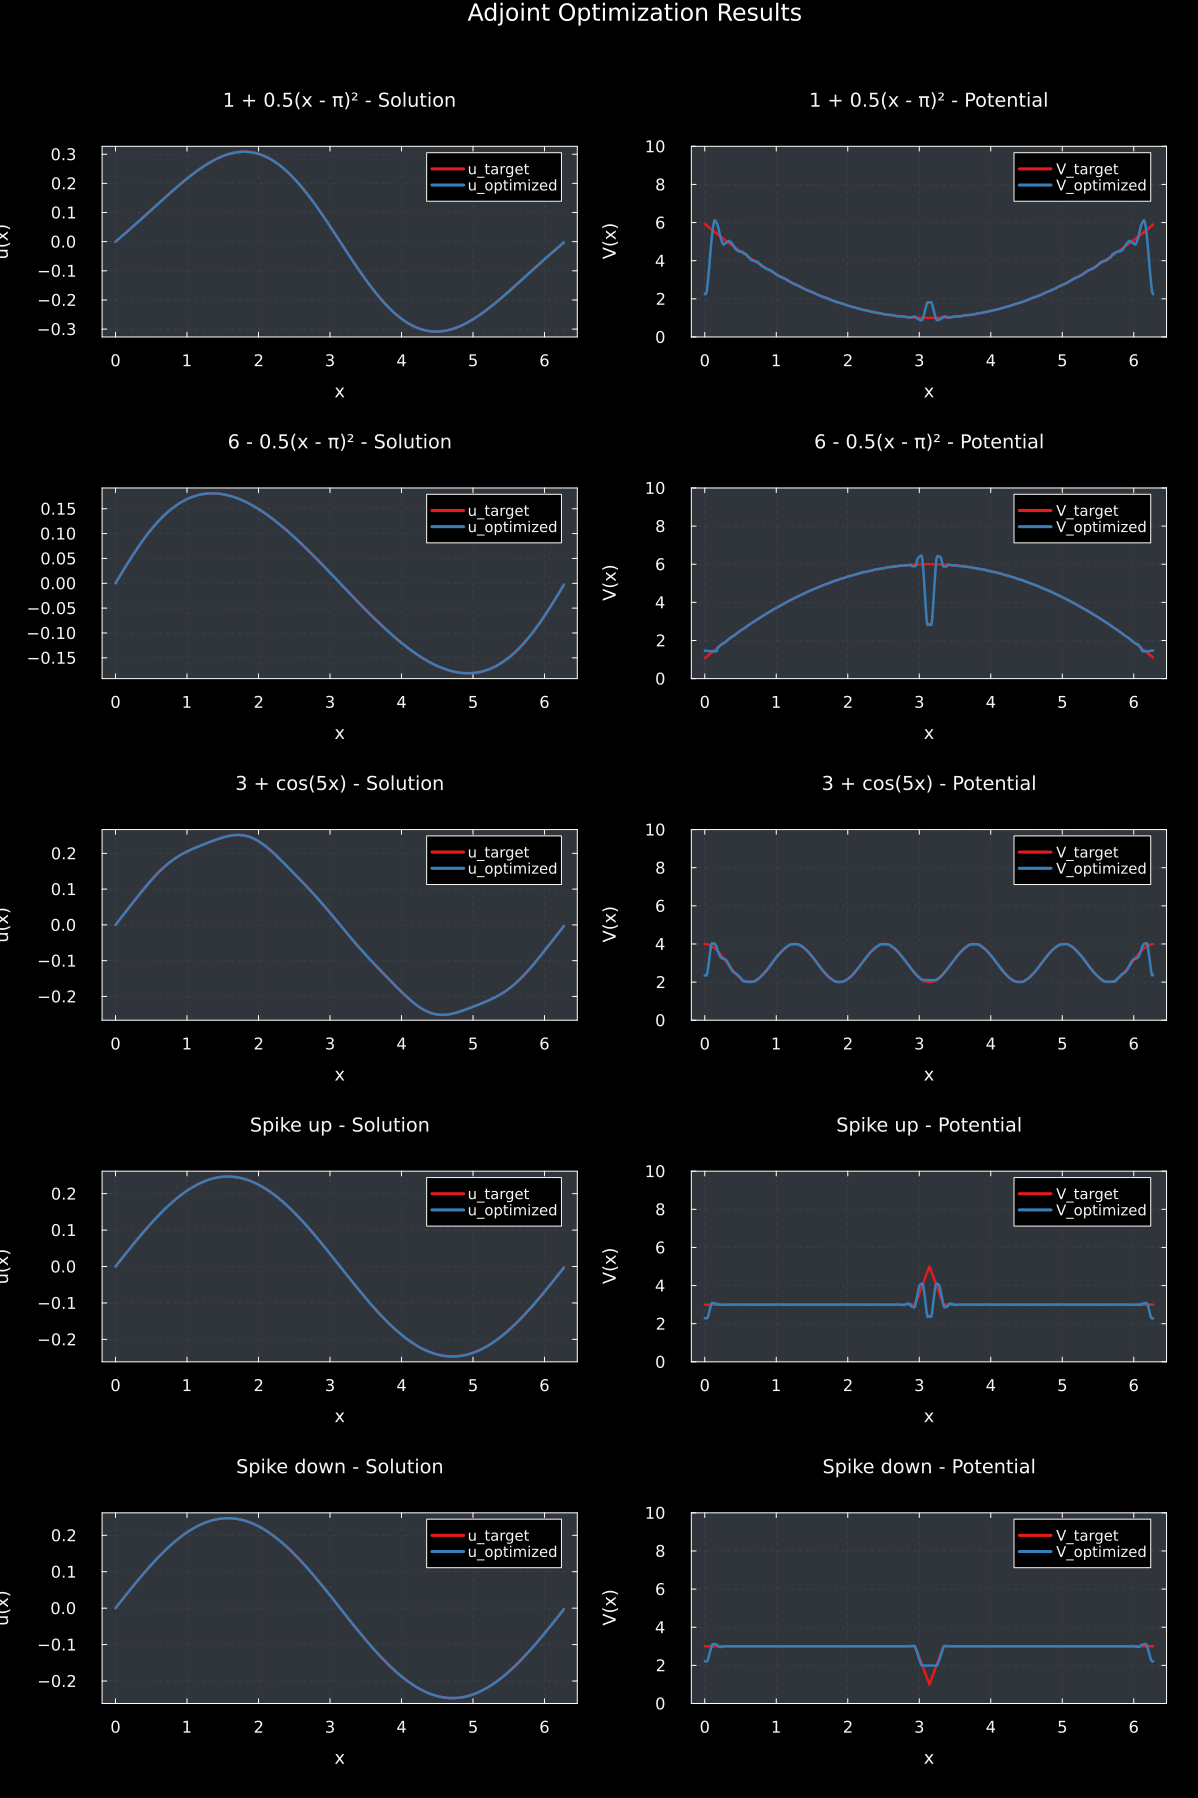

In [29]:
V = 2 .* ones(p.N)
β = 1e-8
# Optimize for each target
V_optimized = []
for i in 1:5

    loss_fn(V) = loss_reg(V; p=p, u_target=u_targets[i, :], R=R_1)
    get_gradient(V) = reg_adjoint_solve(p, V, u_targets[i, :], grad_R=grad_R_1)

    res, st = L_BFGS(loss_fn, get_gradient, V, 1000)
    push!(V_optimized, res)

    println("loss: ", loss(res; p=p, u_target=u_targets[i, :]), ",  V-error: ", round(l2norm(res - targets[:,i]), sigdigits=4),
                "   iters: ", length(st))
end


# Create plots for each target
plots_setup = []

for i in 1:5
    u_sol = Newton_solve(p, V_optimized[i], 20)
    
    p_u = plot(p.x, [u_targets[i, :] u_sol], label=["u_target" "u_optimized"], xlabel="x", ylabel="u(x)", title="$(titles[i]) - Solution", lw=2.5, legend=:topright, size=(600, 400))
    p_V = plot(p.x, [targets[:, i] V_optimized[i]], label=["V_target" "V_optimized"], xlabel="x", ylabel="V(x)", title="$(titles[i]) - Potential", lw=2.5, legend=:topright, ylims=(0, 10), size=(600, 400))
    
    push!(plots_setup, p_u, p_V)
end

plot(plots_setup..., layout=(5, 2), margin=6Plots.mm, size=(1200, 1800), plot_title="Adjoint Optimization Results")

#### Variation of the RHS

The approach is to start solving the PDE for f+c when c is big, then solve for smaller c gradually, using the previous solution as the starting point. This way we make the values at roots converge to better values

In [30]:
function add_after(c, f)
    return x -> f(x) + c
end

add_after (generic function with 1 method)

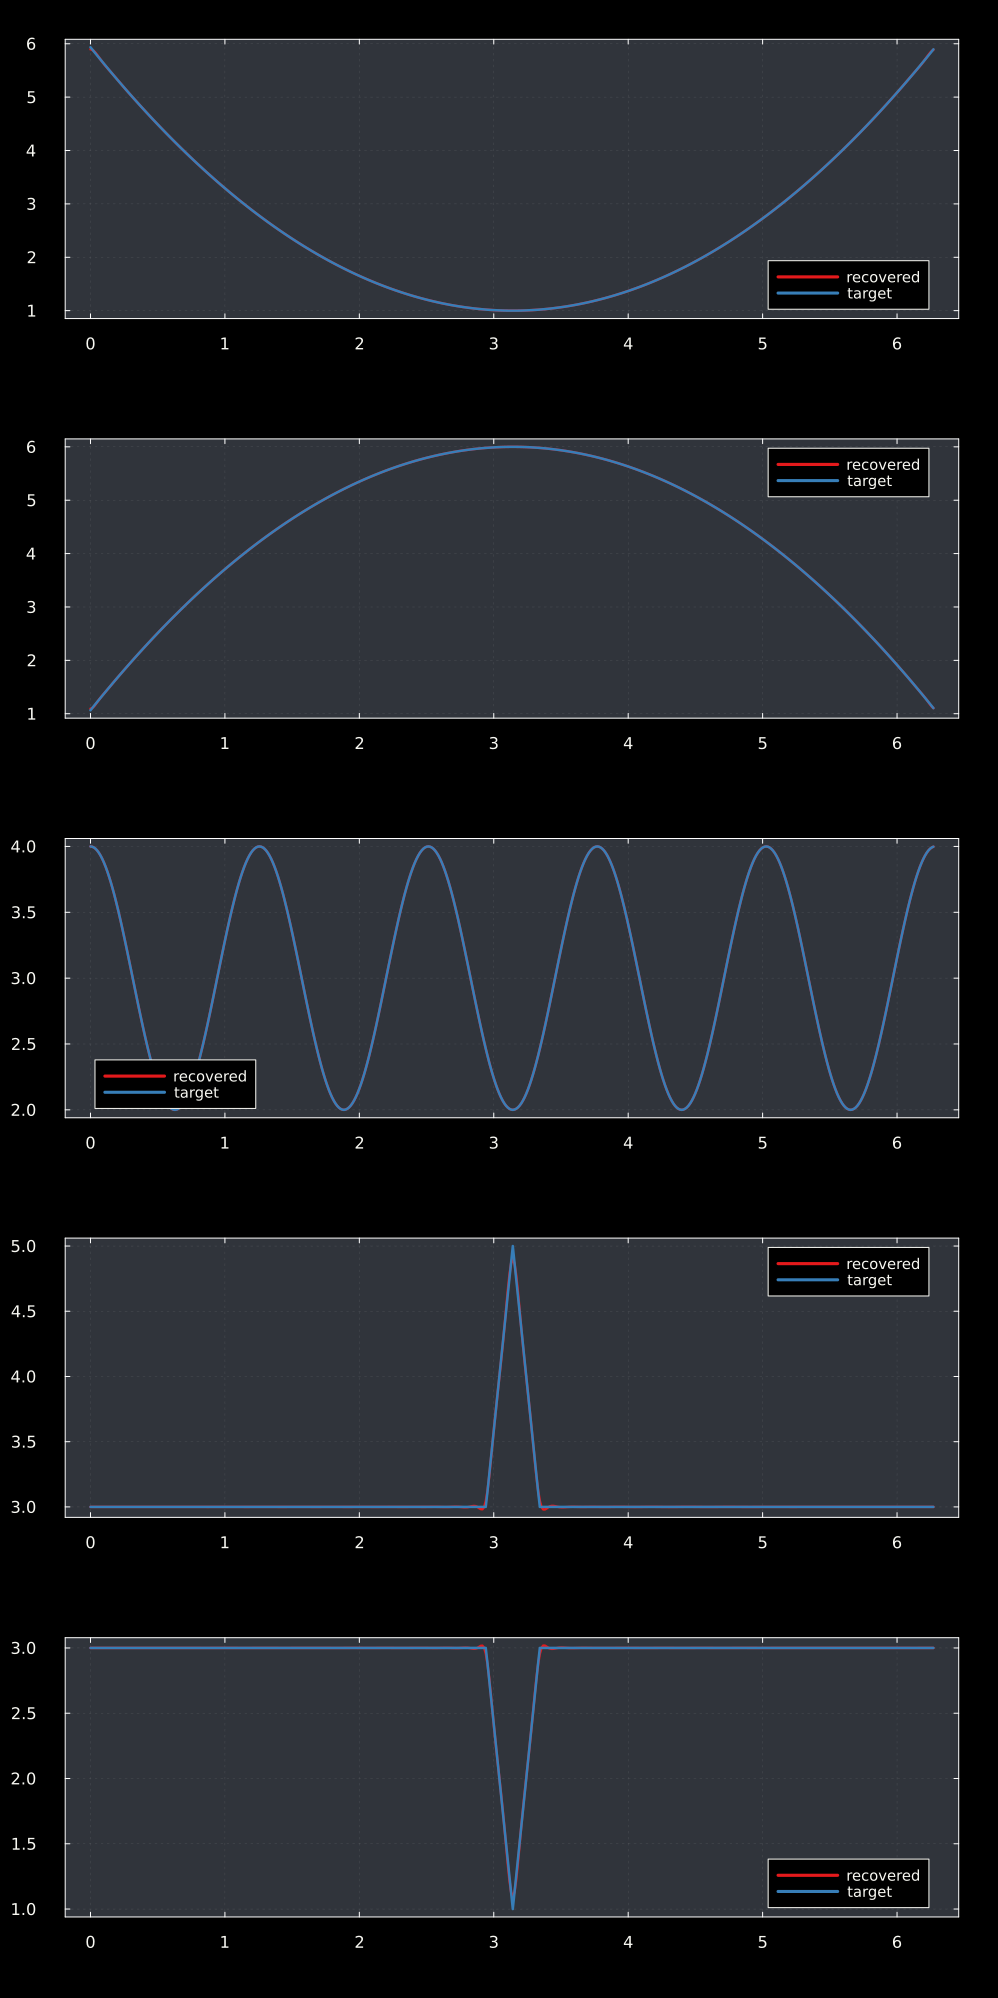

In [31]:
p = Problem(N=500, L=2π, f=f_annuling_fn)
targets, u_targets = create_targets(p)



V= ones(5, p.N) .* 2.0
results_variation = zeros(5, p.N)

cs = [10.0, 5.0, 2.0, 1.0, 0.5, 0.2, 0.1, 0.0]

for c in cs
    p = Problem(N=500, L=2π, f=add_after(c, f_annuling_fn))
    targets, u_targets = create_targets(p)
    for i in 1:5
        V[i, :], _ = L_BFGS(v -> loss(v; p=p, u_target=u_targets[i, :]), v -> adjoint_solve(p, v, u_targets[i, :]), V[i, :], 100)
    end
end

for i in 1:5
    results_variation[i, :], _ = L_BFGS(v -> loss(v; p=p, u_target=u_targets[i, :]), v -> adjoint_solve(p, v, u_targets[i, :]), V[i, :], 1000)
end

plots = []
for i in 1:5
    pl = plot(p.x, [results_variation[i, :] targets[:,i]], label=["recovered" "target"])
    push!(plots, pl)
end
plot(plots..., layout=(5, 1), size=(1000, 2000))


In [32]:
# Create a summary table for the variation of RHS results
p = Problem(N=500, L=2π, f=f_annuling_fn)
targets, u_targets = create_targets(p)
results = Float64[]

# Re-run R2 optimization to get fresh results
V_R2 = ones(5, p.N) .* 2.0
β = 1e-9
for i in 1:5
    loss_fn(V) = loss_reg(V; p=p, u_target=u_targets[i, :], R=R_2)
    get_gradient(V) = reg_adjoint_solve(p, V, u_targets[i, :], grad_R=grad_R_2)
    V_R2[i, :], _ = L_BFGS(loss_fn, get_gradient, V_R2[i, :], 1000)
end

final_losses_R2 = [loss(V_R2[i, :]; p=p, u_target=u_targets[i, :]) for i in 1:5]
V_errors_R2 = [l2norm(V_R2[i, :] - targets[:, i]) for i in 1:5]

# Re-run R1 optimization to get fresh results
V_R1 = ones(5, p.N) .* 2.0
β = 1e-9
for i in 1:5
    loss_fn(V) = loss_reg(V; p=p, u_target=u_targets[i, :], R=R_1)
    get_gradient(V) = reg_adjoint_solve(p, V, u_targets[i, :], grad_R=grad_R_1)
    V_R1[i, :], _ = L_BFGS(loss_fn, get_gradient, V_R1[i, :], 1000)
end

final_losses_R1 = [loss(V_R1[i, :]; p=p, u_target=u_targets[i, :]) for i in 1:5]
V_errors_R1 = [l2norm(V_R1[i, :] - targets[:, i]) for i in 1:5]

# Prepare comparison tables - Loss comparison
loss_data = hcat(final_losses_R2, final_losses_R1, [loss(results_variation[i, :]; p=p, u_target=u_targets[i, :]) for i in 1:5])
pretty_table(
    hcat(reshape(titles, 5), loss_data),
    column_labels = ["Target", "R2 Loss", "R1 Loss", "Variation Loss"],
    title = "Loss Comparison - Regularization Methods")

# V-Error comparison
V_error_data = hcat(V_errors_R2, V_errors_R1, [l2norm(results_variation[i, :] - targets[:, i]) for i in 1:5])
pretty_table(
    hcat(reshape(titles, 5), V_error_data),
    column_labels = ["Target", "R2 V-Error", "R1 V-Error", "Variation V-Error"],
    title = "V-Error Comparison - Regularization Methods")

            Loss Comparison - Regularization Methods
┌─────────────────┬─────────────┬─────────────┬────────────────┐
│          Target │     R2 Loss │     R1 Loss │ Variation Loss │
├─────────────────┼─────────────┼─────────────┼────────────────┤
│ 1 + 0.5(x - π)² │  1.91933e-8 │  2.68132e-8 │    4.03349e-13 │
│ 6 - 0.5(x - π)² │ 1.40267e-10 │  3.40537e-9 │    1.41179e-13 │
│     3 + cos(5x) │  1.65714e-9 │   2.5604e-9 │    2.27611e-16 │
│        Spike up │  2.95404e-9 │  4.11392e-9 │    4.46012e-12 │
│      Spike down │ 7.21159e-10 │ 7.68756e-10 │    2.44546e-12 │
└─────────────────┴─────────────┴─────────────┴────────────────┘
           V-Error Comparison - Regularization Methods
┌─────────────────┬────────────┬────────────┬───────────────────┐
│          Target │ R2 V-Error │ R1 V-Error │ Variation V-Error │
├─────────────────┼────────────┼────────────┼───────────────────┤
│ 1 + 0.5(x - π)² │   0.427776 │      0.505 │        0.00228944 │
│ 6 - 0.5(x - π)² │  0.0180017 │   0.462585

## System solvability analysis

We can make the observation that the `f_annul` and `f - 2` both are just sums of sines and cosines, and moreover those sines and cosines are $2\pi$ periodic, so the integral of these functions over $[0, 2\pi]$ is null. 
For these forcing terms we had that the solutions for different `V`s were really close together, so solving for V becomes harder, as tiniest changes in u_target produce very big changes in the potential V. 

We can look why this happens mathematically. We look back at our adjoint gradient derivation where we got $\delta u$ in terms of $\delta V$.

$$ \delta u = -L^{-1} \text{diag}(u) \delta V$$
this means that at an optimization step, we can quantify the conditioning with the condition number of $-L^{-1} \text{diag}(u)$ 

If we integrate both sides of our differential equation
$$\int_0^{2\pi} -u''(x) + αu(x)^3 + V(x)u(x) dx = \int_0^{2\pi} f(x) dx$$

$$ u'(0)-u'(2\pi) + \int_0^{2\pi} αu(x)^3 + V(x)u(x) dx= \int_0^{2\pi} f(x) dx$$
By our periodicity conditions $ u'(0)-u'(2\pi)$ vanishes

$$\int_0^{2\pi} (αu(x)^2 + V(x))u(x) dx = \int _0^{2\pi} f(x) dx$$

V(x) is a positive function and $\alpha u(x)^2$ is also positive when $\alpha$ is positive so this means that if f is a zero mean function in some parts $u(x)$ is positive and others it is negative, so by continuity and IVT we get that u(x) annuls. This means that we would have a near 0 term in our $\text{diag}(u)$ thus making it near singular and the condition number would blow up. 


In [33]:
using LinearAlgebra

function forward_jacobian(p, V)
    u = Newton_solve(p, V, newton_steps)
    L = -D2 + Diagonal(3p.α .* u.^2 .+ V)

    return u, -(L \ Diagonal(u))
end

cs = -10:0.05:10
αs = 0.0:5.0:100.0


conds = zeros(length(αs), length(cs))
σmins = zeros(length(αs), length(cs))
umins = zeros(length(αs), length(cs))

for (j, α) in enumerate(αs)
    p = Problem(N=500, L=2π, f=f_fn, α=α)
    setup_naive_ad()    
    c_zero = sum(p.f)/p.N 

    for (i, c) in enumerate(cs)
        p = Problem(N=500, L=2π, f=add_after(-c, f_fn), α=α)
        u, J = forward_jacobian(p, ones(p.N))
        s = svdvals(J)
        conds[j, i] = s[1]/s[end]; 
        σmins[j, i] = s[end]; 
        umins[j, i] = minimum(abs.(u))
    end
end


[ Info: Saved animation to /run/media/sipanb/Data/University/stage_levitt/Adjoint_solver/notebooks/jacobian_conditioning.gif


Plots.AnimatedGif("/run/media/sipanb/Data/University/stage_levitt/Adjoint_solver/notebooks/jacobian_conditioning.gif")
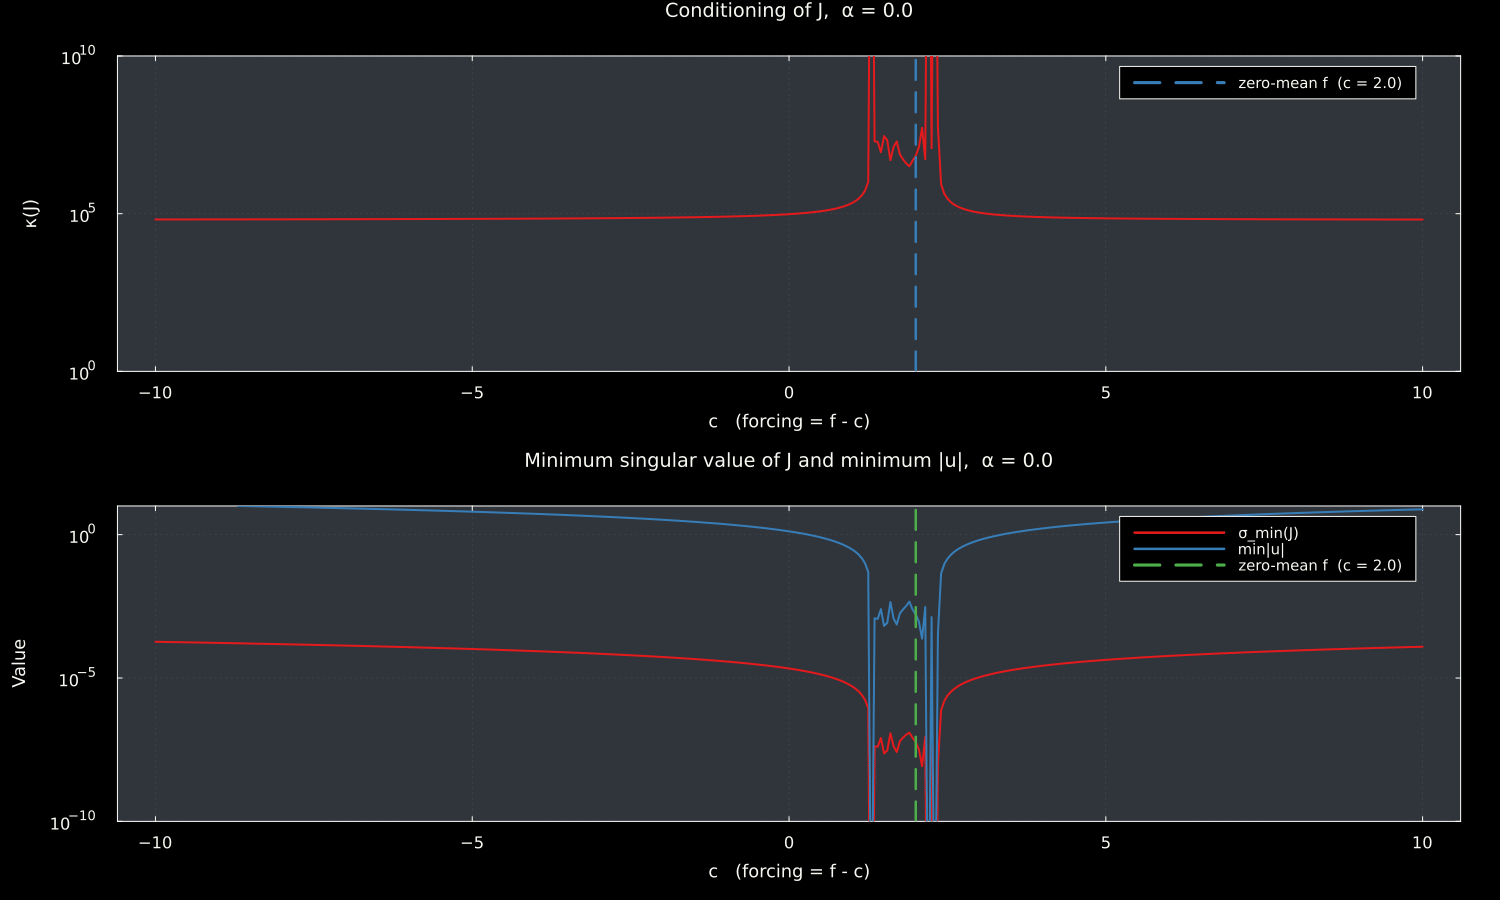

In [34]:
p = Problem(N=500, L=2π, f=f_fn, α=α)

c_zero = sum(p.f)/p.N 

anim = @animate for j in 1:length(αs)

    p1 = plot(cs, conds[j, :], yscale=:log10, xlabel="c   (forcing = f - c)", ylabel="κ(J)", lw=2, label="",
          title="Conditioning of J,  α = $(round(αs[j], digits=2))", ylims=(1, 1e10))
    vline!(p1, [c_zero], ls=:dash, label="zero-mean f  (c = $(round(c_zero, digits=2)))")
    p2 = plot(cs, [σmins[j, :] umins[j, :]], yscale=:log10, xlabel="c   (forcing = f - c)", ylabel="Value", lw=2, label=["σ_min(J)" "min|u|"],
          title="Minimum singular value of J and minimum |u|,  α = $(round(αs[j], digits=2))", ylims=(1e-10, 10))
    vline!(p2, [c_zero], ls=:dash, label="zero-mean f  (c = $(round(c_zero, digits=2)))")

    plot(p1, p2, layout=(2,1), size=(1500, 900))
end

gif(anim, "jacobian_conditioning.gif", fps=1)